# PotholeLens — Final GPU-safe Kaggle notebook

**Project:** PotholeLens: Explainable Edge-AI for Road Damage Detection and Maintenance Prioritisation  
**Dataset:** RDD2022 Kaggle mirror (`aliabdelmenam/rdd-2022`)  
**Models compared:** `YOLOv8s`, `YOLOv8m`, `YOLO11s`  
**Target:** 85%+ image-level damage accuracy and/or 85%+ operating precision where the trained model supports it.

This notebook is designed for Kaggle GPU limits. It fixes the previous CUDA out-of-memory error by avoiding large-list prediction during threshold tuning. Predictions for threshold tuning are performed safely one image at a time.

UREC1 alignment: secondary published dataset only; no human participants; no interviews/surveys; no field image collection; no human evaluation/user testing.

In [1]:

# 0. Install dependencies

%pip install -q ultralytics opencv-python-headless pandas numpy matplotlib tqdm pyyaml scikit-learn flask pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.4 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:

# 1. Imports and memory-safe setup

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc, json, random, shutil, time, zipfile
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from sklearn.metrics import confusion_matrix
from tqdm.auto import tqdm

import torch
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    device = 0
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory GB:", round(torch.cuda.get_device_properties(0).total_memory/(1024**3), 2))
else:
    device = "cpu"
    print("GPU not available; training will be slow.")

print("Torch:", torch.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU: Tesla T4
GPU memory GB: 14.56
Torch: 2.10.0+cu128


In [3]:
# ============================================================
# 2. Main configuration
# ============================================================
# Use gpu_safe first because you are close to Kaggle GPU limits.
RUN_MODE = "gpu_safe"     # options: "gpu_safe", "high_accuracy"
TARGET_SCORE = 0.85

# Requested final comparison models only.
MODEL_CANDIDATES = ["yolov8s.pt", "yolov8m.pt", "yolo11s.pt"]

if RUN_MODE == "gpu_safe":
    IMG_SIZE = 512
    QUICK_EPOCHS = 2
    FINAL_EPOCHS = 8
    TRAIN_LIMIT = 4500
    VAL_LIMIT = 600
    TEST_LIMIT = 700
    THRESH_VAL_LIMIT = 250
    THRESH_TEST_LIMIT = 350
elif RUN_MODE == "high_accuracy":
    IMG_SIZE = 640
    QUICK_EPOCHS = 3
    FINAL_EPOCHS = 15
    TRAIN_LIMIT = 8000
    VAL_LIMIT = 1000
    TEST_LIMIT = 1200
    THRESH_VAL_LIMIT = 500
    THRESH_TEST_LIMIT = 700
else:
    raise ValueError("RUN_MODE must be gpu_safe or high_accuracy")

MODEL_BATCH = {
    "yolov8s.pt": 16 if RUN_MODE == "gpu_safe" else 12,
    "yolov8m.pt": 8 if RUN_MODE == "gpu_safe" else 6,
    "yolo11s.pt": 14 if RUN_MODE == "gpu_safe" else 10,
}

PROJECT_DIR = Path("/kaggle/working/potholelens_final_gpu_safe")
LOCAL_DATASET_DIR = PROJECT_DIR / "rdd2022_subset"
RUNS_DIR = PROJECT_DIR / "runs"
APP_DIR = PROJECT_DIR / "flask_app"
OUTPUT_DIR = PROJECT_DIR / "outputs"
for p in [PROJECT_DIR, LOCAL_DATASET_DIR, RUNS_DIR, APP_DIR, OUTPUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {
    0: "longitudinal_crack",
    1: "transverse_crack",
    2: "alligator_crack",
    3: "other_corruption",
    4: "pothole",
}
NC = len(CLASS_NAMES)

print("RUN_MODE:", RUN_MODE)
print("IMG_SIZE:", IMG_SIZE)
print("MODELS:", MODEL_CANDIDATES)
print("SUBSET LIMITS:", TRAIN_LIMIT, VAL_LIMIT, TEST_LIMIT)

RUN_MODE: gpu_safe
IMG_SIZE: 512
MODELS: ['yolov8s.pt', 'yolov8m.pt', 'yolo11s.pt']
SUBSET LIMITS: 4500 600 700


In [4]:
# ============================================================
# 3. Locate RDD2022 dataset on Kaggle
# ============================================================
def find_rdd_root():
    candidates = [
        Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT"),
        Path("/kaggle/input/rdd-2022/RDD_SPLIT"),
        Path("/kaggle/input/rdd2022/RDD_SPLIT"),
    ]
    for c in candidates:
        if (c / "train" / "images").exists() and (c / "train" / "labels").exists():
            return c
    for p in Path("/kaggle/input").rglob("RDD_SPLIT"):
        if (p / "train" / "images").exists() and (p / "train" / "labels").exists():
            return p
    raise FileNotFoundError("RDD_SPLIT not found. Add Kaggle dataset: aliabdelmenam/rdd-2022")

SOURCE_ROOT = find_rdd_root()
print("RDD2022 source root:", SOURCE_ROOT)
for split in ["train", "val", "test"]:
    print(split, len(list((SOURCE_ROOT/split/"images").glob("*.*"))), "images")

RDD2022 source root: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT
train 26869 images
val 5758 images
test 5758 images


In [5]:
# ============================================================
# 4. Dataset audit and EDA preparation
# ============================================================
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

def list_images(split):
    return sorted([p for p in (SOURCE_ROOT/split/"images").iterdir() if p.suffix.lower() in IMAGE_EXTS])

def label_path_for_image(img_path, root=SOURCE_ROOT):
    split = img_path.parent.parent.name
    return root / split / "labels" / f"{img_path.stem}.txt"

def read_yolo_labels(label_path):
    rows = []
    if not Path(label_path).exists():
        return rows
    for line in Path(label_path).read_text(encoding="utf-8", errors="ignore").splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        try:
            cls = int(float(parts[0])); xc, yc, w, h = map(float, parts[1:])
            if 0 <= cls < NC:
                rows.append((cls, xc, yc, w, h))
        except Exception:
            pass
    return rows

def country_from_name(path):
    stem = Path(path).stem
    if stem.startswith("United_States"):
        return "United_States"
    return stem.split("_")[0]

def build_split_audit(split):
    rows=[]
    for img_path in list_images(split):
        labels = read_yolo_labels(label_path_for_image(img_path))
        cc = Counter([x[0] for x in labels])
        row = {"split":split,"image_path":str(img_path),"filename":img_path.name,"country":country_from_name(img_path),"has_damage":int(len(labels)>0),"num_boxes":len(labels)}
        for c in range(NC): row[f"class_{c}"] = cc.get(c,0)
        rows.append(row)
    return pd.DataFrame(rows)

audit_df = pd.concat([build_split_audit(s) for s in ["train","val","test"]], ignore_index=True)
display(audit_df.head())
display(audit_df.groupby("split").agg(images=("filename","count"), damaged=("has_damage","sum"), boxes=("num_boxes","sum")))
audit_df.to_csv(OUTPUT_DIR/"dataset_audit.csv", index=False)

,split,image_path,filename,country,has_damage,num_boxes,class_0,class_1,class_2,class_3,class_4
0,train,/kaggle/input/datasets/aliabdelmenam/rdd-2022/...,China_Drone_000001.jpg,China,1,2,1,1,0,0,0
1,train,/kaggle/input/datasets/aliabdelmenam/rdd-2022/...,China_Drone_000002.jpg,China,1,2,2,0,0,0,0
2,train,/kaggle/input/datasets/aliabdelmenam/rdd-2022/...,China_Drone_000003.jpg,China,1,3,1,2,0,0,0
3,train,/kaggle/input/datasets/aliabdelmenam/rdd-2022/...,China_Drone_000005.jpg,China,1,2,1,1,0,0,0
4,train,/kaggle/input/datasets/aliabdelmenam/rdd-2022/...,China_Drone_000009.jpg,China,1,4,4,0,0,0,0


,images,damaged,boxes
split,,,
test,5758,3968,9675
train,26869,18772,46296
val,5758,3921,9741


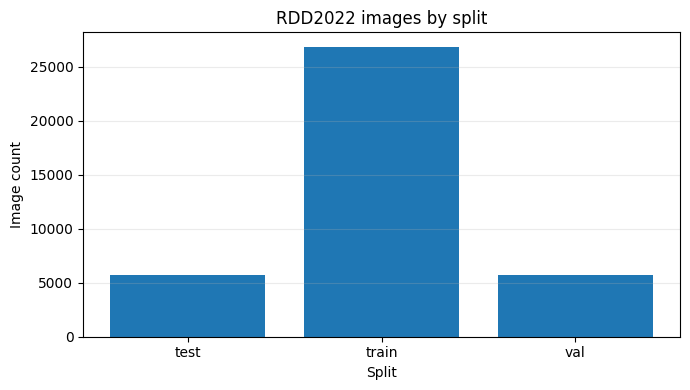

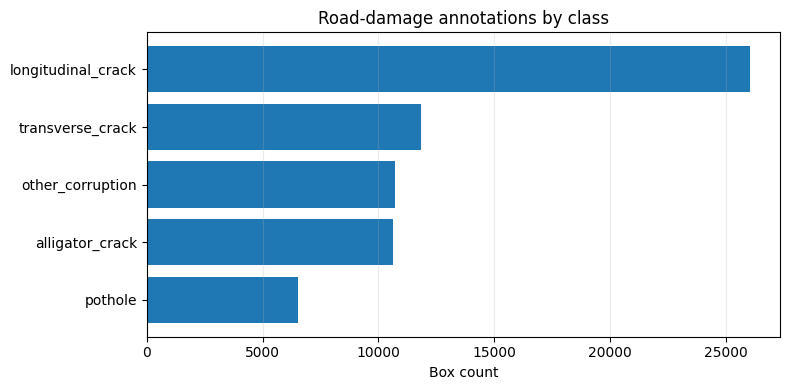

split,test,train,val
country,,,
China,682,3051,645
Czech,436,1962,431
India,1166,5368,1172
Japan,1524,7432,1550
Norway,1197,5708,1256
United_States,753,3348,704


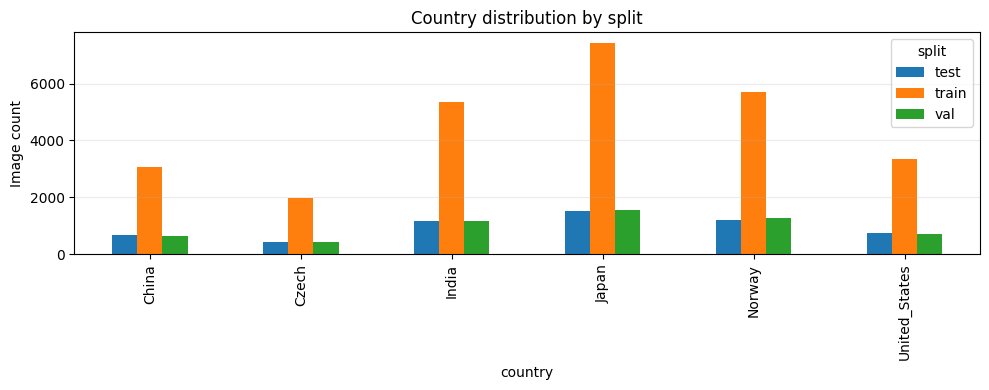

UREC1 reminder: do not reproduce identifiable road-scene images in the report unless cropped/blurred.


In [6]:
# ============================================================
# 5. EDA graphs
# ============================================================
split_summary = audit_df.groupby("split").agg(images=("filename","count"), damaged_images=("has_damage","sum"), boxes=("num_boxes","sum")).reset_index()
plt.figure(figsize=(7,4)); plt.bar(split_summary["split"], split_summary["images"]); plt.title("RDD2022 images by split"); plt.xlabel("Split"); plt.ylabel("Image count"); plt.grid(axis="y", alpha=.25); plt.tight_layout(); plt.show()

class_df = pd.DataFrame({"class":[CLASS_NAMES[i] for i in range(NC)], "boxes":[int(audit_df[f"class_{i}"].sum()) for i in range(NC)]}).sort_values("boxes")
plt.figure(figsize=(8,4)); plt.barh(class_df["class"], class_df["boxes"]); plt.title("Road-damage annotations by class"); plt.xlabel("Box count"); plt.grid(axis="x", alpha=.25); plt.tight_layout(); plt.show()

country_split = audit_df.groupby(["country","split"]).size().reset_index(name="images").pivot(index="country", columns="split", values="images").fillna(0)
display(country_split)
country_split.plot(kind="bar", figsize=(10,4)); plt.title("Country distribution by split"); plt.ylabel("Image count"); plt.grid(axis="y", alpha=.25); plt.tight_layout(); plt.show()

print("UREC1 reminder: do not reproduce identifiable road-scene images in the report unless cropped/blurred.")

In [7]:
# ============================================================
# 6. Balanced subset selection
# ============================================================
def balanced_select(df, limit, split, background_fraction=0.12):
    df = df[df["split"] == split].copy()
    rng = random.Random(SEED + len(split))
    class_to_paths = defaultdict(list)
    for _, row in df.iterrows():
        for c in range(NC):
            if row[f"class_{c}"] > 0:
                class_to_paths[c].append(row["image_path"])
    for c in range(NC): rng.shuffle(class_to_paths[c])
    selected=[]; seen=set()
    target_damage = int(limit*(1-background_fraction))
    while len(selected) < target_damage:
        changed=False
        for c in range(NC):
            while class_to_paths[c]:
                p = class_to_paths[c].pop()
                if p not in seen:
                    selected.append(p); seen.add(p); changed=True; break
            if len(selected) >= target_damage: break
        if not changed: break
    bg = df[df["num_boxes"]==0]["image_path"].tolist(); rng.shuffle(bg)
    for p in bg:
        if len(selected) >= limit: break
        if p not in seen: selected.append(p); seen.add(p)
    rem = df["image_path"].tolist(); rng.shuffle(rem)
    for p in rem:
        if len(selected) >= limit: break
        if p not in seen: selected.append(p); seen.add(p)
    rng.shuffle(selected)
    return [Path(p) for p in selected[:limit]]

selected_by_split = {
    "train": balanced_select(audit_df, TRAIN_LIMIT, "train", 0.12),
    "val": balanced_select(audit_df, VAL_LIMIT, "val", 0.10),
    "test": balanced_select(audit_df, TEST_LIMIT, "test", 0.10),
}
for split, paths in selected_by_split.items(): print(split, len(paths))

train 4500
val 600
test 700


In [8]:
# ============================================================
# 7. Create local working subset
# ============================================================
def reset_dir(path):
    if Path(path).exists(): shutil.rmtree(path)
    Path(path).mkdir(parents=True, exist_ok=True)

def copy_or_link(src, dst):
    dst = Path(dst); dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists(): return
    try:
        shutil.copy2(src, dst)
    except Exception:
        try: os.symlink(src, dst)
        except Exception: shutil.copyfile(src, dst)

reset_dir(LOCAL_DATASET_DIR)
manifest=[]
for split, paths in selected_by_split.items():
    (LOCAL_DATASET_DIR/"images"/split).mkdir(parents=True, exist_ok=True)
    (LOCAL_DATASET_DIR/"labels"/split).mkdir(parents=True, exist_ok=True)
    for src_img in tqdm(paths, desc=f"Preparing {split}"):
        src_lab = label_path_for_image(src_img)
        dst_img = LOCAL_DATASET_DIR/"images"/split/src_img.name
        dst_lab = LOCAL_DATASET_DIR/"labels"/split/f"{src_img.stem}.txt"
        copy_or_link(src_img, dst_img)
        if src_lab.exists(): copy_or_link(src_lab, dst_lab)
        else: dst_lab.write_text("", encoding="utf-8")
        labels = read_yolo_labels(src_lab)
        manifest.append({"split":split,"image":str(dst_img),"label":str(dst_lab),"filename":src_img.name,"has_damage":int(len(labels)>0),"num_boxes":len(labels)})
manifest_df = pd.DataFrame(manifest)
display(manifest_df.groupby("split").agg(images=("image","count"), damaged=("has_damage","sum"), boxes=("num_boxes","sum")))
manifest_df.to_csv(OUTPUT_DIR/"subset_manifest.csv", index=False)

Preparing train:   0%|          | 0/4500 [00:00<?, ?it/s]

Preparing val:   0%|          | 0/600 [00:00<?, ?it/s]

Preparing test:   0%|          | 0/700 [00:00<?, ?it/s]

,images,damaged,boxes
split,,,
test,700,630,1848
train,4500,3960,11523
val,600,540,1585


In [9]:
# ============================================================
# 8. YOLO dataset YAML
# ============================================================
data_yaml = PROJECT_DIR / "potholelens_rdd2022_gpu_safe.yaml"
yaml_data = {"path": str(LOCAL_DATASET_DIR.resolve()), "train":"images/train", "val":"images/val", "test":"images/test", "nc":NC, "names":CLASS_NAMES}
data_yaml.write_text(yaml.safe_dump(yaml_data, sort_keys=False), encoding="utf-8")
print(data_yaml.read_text())

path: /kaggle/working/potholelens_final_gpu_safe/rdd2022_subset
train: images/train
val: images/val
test: images/test
nc: 5
names:
  0: longitudinal_crack
  1: transverse_crack
  2: alligator_crack
  3: other_corruption
  4: pothole



In [10]:
# ============================================================
# 9. Utility functions
# ============================================================
def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def f1_from_pr(p, r):
    return 2*p*r/max(p+r, 1e-12)

def safe_speed_from_val(val_result):
    speed = getattr(val_result, "speed", {}) or {}
    return float(speed.get("inference", np.nan))

def batch_for(model_name):
    return MODEL_BATCH.get(model_name, 8)

clear_gpu()

In [11]:
# ============================================================
# 10. Quick comparison of YOLOv8s, YOLOv8m and YOLO11s
# ============================================================
screen_records=[]
for backbone in MODEL_CANDIDATES:
    print("\n" + "="*80); print("Quick screening model:", backbone); print("="*80)
    clear_gpu()
    model = YOLO(backbone)
    run_name = f"screen_{Path(backbone).stem}_{IMG_SIZE}"
    start=time.time()
    train_results = model.train(
        data=str(data_yaml), imgsz=IMG_SIZE, epochs=QUICK_EPOCHS, batch=batch_for(backbone), device=device,
        seed=SEED, project=str(RUNS_DIR), name=run_name, pretrained=True, exist_ok=True,
        optimizer="AdamW", lr0=0.001, lrf=0.02, weight_decay=0.0005, cos_lr=True,
        patience=max(2, QUICK_EPOCHS), val=False, plots=False, cache="disk", workers=2,
        degrees=4.0, translate=0.04, scale=0.25, perspective=0.0003, fliplr=0.5,
        hsv_h=0.015, hsv_s=0.25, hsv_v=0.20, mosaic=0.35, mixup=0.0, close_mosaic=1,
        verbose=False)
    best_path = Path(train_results.save_dir)/"weights"/"best.pt"
    if not best_path.exists(): best_path = Path(train_results.save_dir)/"weights"/"last.pt"
    del model; clear_gpu()
    eval_model = YOLO(str(best_path))
    val_eval = eval_model.val(data=str(data_yaml), split="val", imgsz=IMG_SIZE, conf=0.001, iou=0.50, batch=1, device=device, plots=False, verbose=False)
    p=float(val_eval.box.mp); r=float(val_eval.box.mr)
    rec={"model":backbone,"weights":str(best_path),"run_dir":str(Path(train_results.save_dir)),"minutes":(time.time()-start)/60,
         "precision":p,"recall":r,"F1":f1_from_pr(p,r),"mAP50":float(val_eval.box.map50),"mAP50_95":float(val_eval.box.map),"speed_inference_ms":safe_speed_from_val(val_eval)}
    print(rec); screen_records.append(rec)
    del eval_model; clear_gpu()

screen_df = pd.DataFrame(screen_records).sort_values("mAP50", ascending=False).reset_index(drop=True)
display(screen_df)
screen_df.to_csv(OUTPUT_DIR/"quick_model_comparison.csv", index=False)


Quick screening model: yolov8s.pt
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, channels_last=False, classes=None, close_mosaic=1, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/potholelens_final_gpu_safe/potholelens_rdd2022_gpu_safe.yaml, degrees=4.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.25, hsv_v=0.2, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.02, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, mo

,model,weights,run_dir,minutes,precision,recall,F1,mAP50,mAP50_95,speed_inference_ms
0,yolov8s.pt,/kaggle/working/potholelens_final_gpu_safe/run...,/kaggle/working/potholelens_final_gpu_safe/run...,3.999987,0.342893,0.296960,0.318278,0.256168,0.090277,18.996560
1,yolov8m.pt,/kaggle/working/potholelens_final_gpu_safe/run...,/kaggle/working/potholelens_final_gpu_safe/run...,5.298652,0.382082,0.283465,0.325467,0.250958,0.092065,38.102786
2,yolo11s.pt,/kaggle/working/potholelens_final_gpu_safe/run...,/kaggle/working/potholelens_final_gpu_safe/run...,4.785172,0.342586,0.288248,0.313077,0.240263,0.081206,16.515546


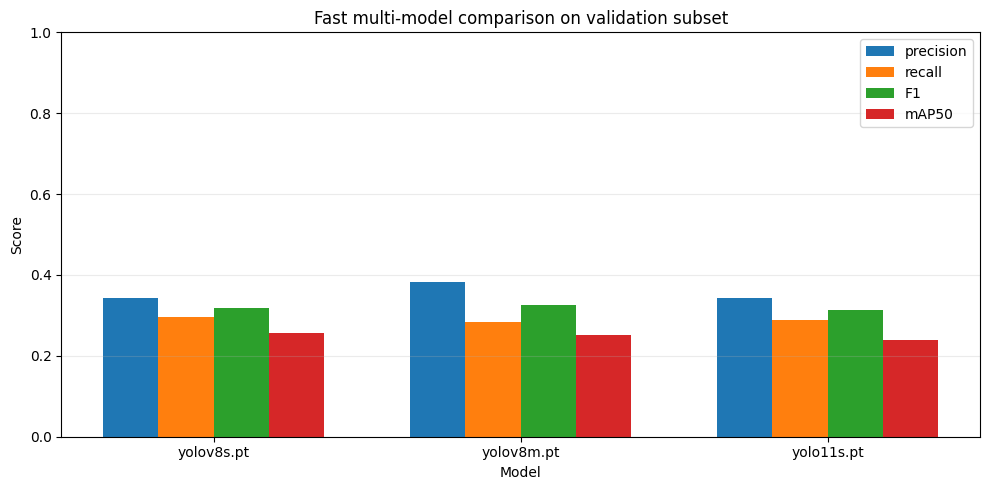

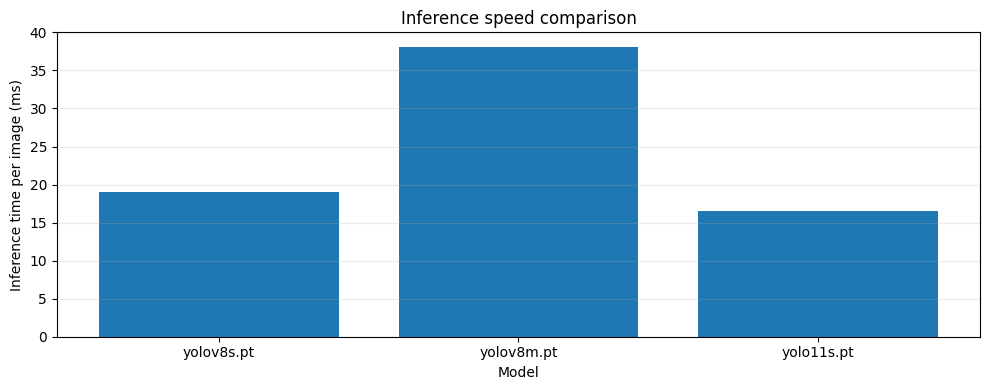

Best quick model: yolov8s.pt
Best quick weights: /kaggle/working/potholelens_final_gpu_safe/runs/screen_yolov8s_512/weights/best.pt


In [12]:
# ============================================================
# 11. Comparison charts and best model selection
# ============================================================
plot_df = screen_df.copy()
plt.figure(figsize=(10,5))
x=np.arange(len(plot_df)); width=.18
for i, metric in enumerate(["precision","recall","F1","mAP50"]):
    plt.bar(x+(i-1.5)*width, plot_df[metric], width=width, label=metric)
plt.xticks(x, plot_df["model"]); plt.ylim(0,1); plt.title("Fast multi-model comparison on validation subset"); plt.xlabel("Model"); plt.ylabel("Score"); plt.grid(axis="y", alpha=.25); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,4)); plt.bar(plot_df["model"], plot_df["speed_inference_ms"]); plt.title("Inference speed comparison"); plt.xlabel("Model"); plt.ylabel("Inference time per image (ms)"); plt.grid(axis="y", alpha=.25); plt.tight_layout(); plt.show()

# Accuracy/runtime-aware selection. mAP50 is primary, F1 secondary, speed penalty small.
tmp = plot_df.copy()
tmp["speed_fill"] = tmp["speed_inference_ms"].fillna(tmp["speed_inference_ms"].median() if tmp["speed_inference_ms"].notna().any() else 10)
tmp["selection_score"] = tmp["mAP50"] + 0.25*tmp["F1"] - 0.0005*tmp["speed_fill"]
best_row = tmp.sort_values("selection_score", ascending=False).iloc[0]
BEST_QUICK_MODEL = str(best_row["model"])
BEST_QUICK_WEIGHTS = Path(best_row["weights"])
print("Best quick model:", BEST_QUICK_MODEL)
print("Best quick weights:", BEST_QUICK_WEIGHTS)

In [13]:
# ============================================================
# 12. Final fine-tuning of selected model only
# ============================================================
clear_gpu()
FINAL_MODEL_NAME = BEST_QUICK_MODEL
FINAL_START_WEIGHTS = BEST_QUICK_WEIGHTS
FINAL_RUN_NAME = f"final_{Path(FINAL_MODEL_NAME).stem}_{IMG_SIZE}_{RUN_MODE}"
print("Final model:", FINAL_MODEL_NAME)
print("Start weights:", FINAL_START_WEIGHTS)
print("Final epochs:", FINAL_EPOCHS)

final_model = YOLO(str(FINAL_START_WEIGHTS))
final_train = final_model.train(
    data=str(data_yaml), imgsz=IMG_SIZE, epochs=FINAL_EPOCHS, batch=batch_for(FINAL_MODEL_NAME), device=device,
    seed=SEED, project=str(RUNS_DIR), name=FINAL_RUN_NAME, pretrained=True, exist_ok=True,
    optimizer="AdamW", lr0=0.0006, lrf=0.015, weight_decay=0.0005, cos_lr=True, patience=max(4, FINAL_EPOCHS//2),
    val=False, plots=True, cache="disk", workers=2,
    degrees=4.0, translate=0.04, scale=0.25, perspective=0.0003, fliplr=0.5,
    hsv_h=0.015, hsv_s=0.25, hsv_v=0.20, mosaic=0.25, mixup=0.0, close_mosaic=max(1, FINAL_EPOCHS//3),
    verbose=True)
FINAL_MODEL_PATH = Path(final_train.save_dir)/"weights"/"best.pt"
if not FINAL_MODEL_PATH.exists(): FINAL_MODEL_PATH = Path(final_train.save_dir)/"weights"/"last.pt"
print("Final model path:", FINAL_MODEL_PATH)
del final_model; clear_gpu()

Final model: yolov8s.pt
Start weights: /kaggle/working/potholelens_final_gpu_safe/runs/screen_yolov8s_512/weights/best.pt
Final epochs: 8
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, channels_last=False, classes=None, close_mosaic=2, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/potholelens_final_gpu_safe/potholelens_rdd2022_gpu_safe.yaml, degrees=4.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=8, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.25, hsv_v=0.2, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_

In [14]:
# ============================================================
# 13. Final validation/test detection metrics
# ============================================================
clear_gpu()
best_model = YOLO(str(FINAL_MODEL_PATH))
val_results = best_model.val(data=str(data_yaml), split="val", imgsz=IMG_SIZE, conf=0.001, iou=0.50, batch=1, device=device, plots=True, verbose=False)
test_results = best_model.val(data=str(data_yaml), split="test", imgsz=IMG_SIZE, conf=0.001, iou=0.50, batch=1, device=device, plots=True, verbose=False)
final_metrics = {
    "model": FINAL_MODEL_NAME, "weights": str(FINAL_MODEL_PATH),
    "val_precision": float(val_results.box.mp), "val_recall": float(val_results.box.mr), "val_F1": f1_from_pr(float(val_results.box.mp), float(val_results.box.mr)), "val_mAP50": float(val_results.box.map50), "val_mAP50_95": float(val_results.box.map),
    "test_precision": float(test_results.box.mp), "test_recall": float(test_results.box.mr), "test_F1": f1_from_pr(float(test_results.box.mp), float(test_results.box.mr)), "test_mAP50": float(test_results.box.map50), "test_mAP50_95": float(test_results.box.map), "test_inference_ms": safe_speed_from_val(test_results)}
final_metrics_df = pd.DataFrame([final_metrics]); display(final_metrics_df)
final_metrics_df.to_csv(OUTPUT_DIR/"final_detection_metrics.csv", index=False)
del best_model; clear_gpu()

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1669.9±756.0 MB/s, size: 201.4 KB)
val: Scanning /kaggle/working/potholelens_final_gpu_safe/rdd2022_subset/labels/val.cache... 600 images, 60 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 600/600 209.7Mit/s 0.0s
val: /kaggle/working/potholelens_final_gpu_safe/rdd2022_subset/images/val/Japan_006536.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 600/600 59.2it/s 10.1s0.1s
                   all        600       1584      0.538      0.452      0.471      0.206
Speed: 1.0ms preprocess, 8.6ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-4
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image 

,model,weights,val_precision,val_recall,val_F1,val_mAP50,val_mAP50_95,test_precision,test_recall,test_F1,test_mAP50,test_mAP50_95,test_inference_ms
0,yolov8s.pt,/kaggle/working/potholelens_final_gpu_safe/run...,0.537924,0.452085,0.491283,0.470612,0.206188,0.514214,0.482503,0.497854,0.45995,0.198511,8.700897


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
3,4,211.413,1.93898,2.25348,1.78617,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.000418,0.000418,0.000418
4,5,264.245,1.86230,2.12531,1.73211,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.000304,0.000304,0.000304
5,6,316.656,1.81450,1.98817,1.69854,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.000191,0.000191,0.000191
6,7,370.604,1.75314,1.84013,1.64789,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.000096,0.000096,0.000096
7,8,432.672,1.71767,1.77529,1.62106,0.52918,0.43451,0.44962,0.20621,1.9515,1.90124,1.67849,0.000031,0.000031,0.000031


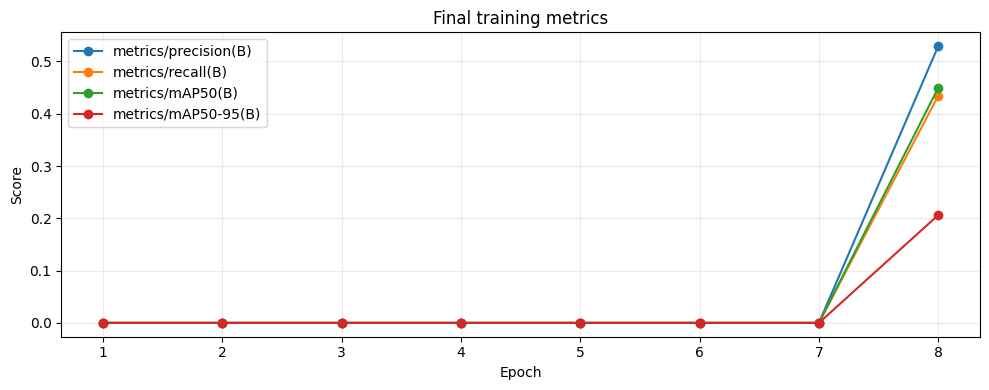

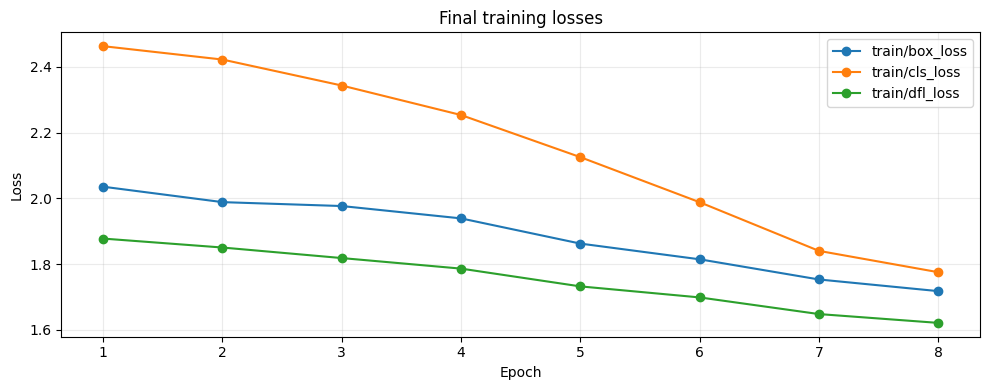

In [ ]:
# ============================================================
# 14. Training curves
# ============================================================
def read_results_csv(run_dir):
    run_dir=Path(run_dir); csv_path=run_dir/"results.csv"
    if not csv_path.exists():
        found=list(run_dir.rglob("results.csv")); csv_path=found[0] if found else None
    if csv_path is None or not Path(csv_path).exists(): return pd.DataFrame()
    df=pd.read_csv(csv_path); df.columns=[c.strip() for c in df.columns]; return df

results_df = read_results_csv(Path(final_train.save_dir))
display(results_df.tail() if len(results_df) else results_df)
if len(results_df):
    metric_cols=[c for c in results_df.columns if "metrics/" in c]
    if metric_cols:
        plt.figure(figsize=(10,4))
        for c in metric_cols: plt.plot(results_df["epoch"], results_df[c], marker="o", label=c)
        plt.title("Final training metrics"); plt.xlabel("Epoch"); plt.ylabel("Score"); plt.grid(alpha=.25); plt.legend(); plt.tight_layout(); plt.show()
    loss_cols=[c for c in results_df.columns if "train/" in c and "loss" in c]
    if loss_cols:
        plt.figure(figsize=(10,4))
        for c in loss_cols: plt.plot(results_df["epoch"], results_df[c], marker="o", label=c)
        plt.title("Final training losses"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(alpha=.25); plt.legend(); plt.tight_layout(); plt.show()

Threshold validation images: 250
Threshold test images: 350


Safe image-level prediction:   0%|          | 0/250 [00:00<?, ?it/s]

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.

,conf_threshold,accuracy,balanced_accuracy,precision,recall,specificity,F1,TP,FP,TN,FN
0,0.05,0.892,0.611486,0.911392,0.972973,0.250000,0.941176,216,21,7,6
1,0.10,0.900,0.740830,0.941704,0.945946,0.535714,0.943820,210,13,15,12
2,0.15,0.884,0.794241,0.957346,0.909910,0.678571,0.933025,202,9,19,20
3,0.20,0.840,0.831885,0.973958,0.842342,0.821429,0.903382,187,5,23,35
4,0.25,0.784,0.800354,0.971910,0.779279,0.821429,0.865000,173,5,23,49
5,0.30,0.732,0.786680,0.975460,0.716216,0.857143,0.825974,159,4,24,63
6,0.35,0.680,0.788610,0.986301,0.648649,0.928571,0.782609,144,2,26,78
7,0.40,0.612,0.750322,0.984496,0.572072,0.928571,0.723647,127,2,26,95
8,0.45,0.548,0.729891,0.990991,0.495495,0.964286,0.660661,110,1,27,112
9,0.50,0.488,0.696107,0.989583,0.427928,0.964286,0.597484,95,1,27,127


Selected threshold: 0.1
Selected because validation image-level accuracy reached at least 85%.


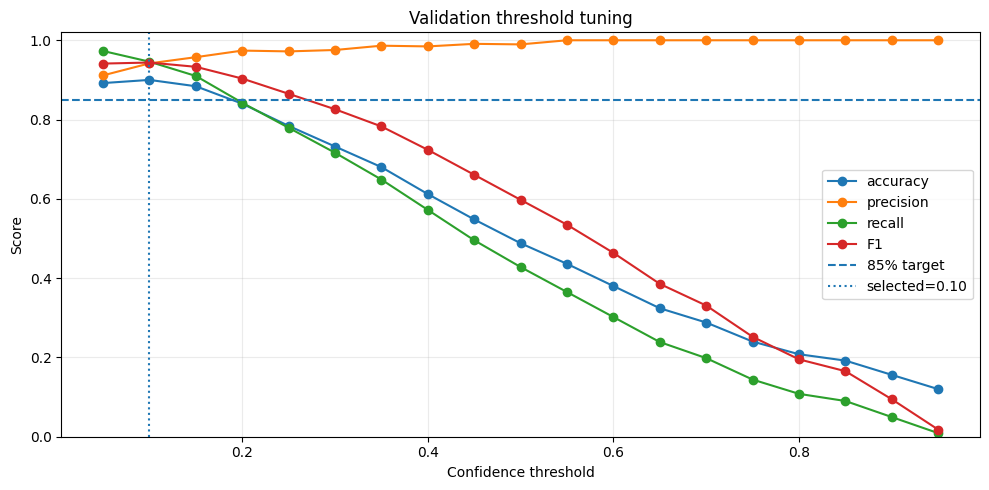

Safe image-level prediction:   0%|          | 0/350 [00:00<?, ?it/s]

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.

,conf_threshold,accuracy,balanced_accuracy,precision,recall,specificity,F1,TP,FP,TN,FN
0,0.1,0.897143,0.725149,0.952077,0.934169,0.516129,0.943038,298,15,16,21


In [ ]:
# ============================================================
# 15. GPU-safe image-level threshold tuning for 85%+ target
# ============================================================
def local_label_path_from_image(img_path):
    img_path=Path(img_path); split=img_path.parent.name
    return LOCAL_DATASET_DIR/"labels"/split/f"{img_path.stem}.txt"

def has_damage_ground_truth(img_path):
    return int(len(read_yolo_labels(local_label_path_from_image(img_path))) > 0)

def get_local_images(split):
    return sorted([p for p in (LOCAL_DATASET_DIR/"images"/split).glob("*.*") if p.suffix.lower() in IMAGE_EXTS])

def collect_image_level_scores_safe(weights_path, image_paths, imgsz=IMG_SIZE, min_conf=0.001):
    # Critical OOM fix: do NOT pass a 1200-image list to model.predict.
    # Load one model, predict one image at a time, batch=1, clear memory regularly.
    clear_gpu()
    model=YOLO(str(weights_path))
    rows=[]
    for i,p in enumerate(tqdm(image_paths, desc="Safe image-level prediction")):
        p=Path(p); y_true=has_damage_ground_truth(p)
        try:
            with torch.inference_mode():
                results=model.predict(source=str(p), imgsz=imgsz, conf=min_conf, iou=0.50, max_det=80, batch=1, device=device, half=bool(torch.cuda.is_available()), verbose=False, stream=False)
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print("OOM during prediction; retrying this image on CPU:", p.name)
                clear_gpu()
                with torch.inference_mode():
                    results=model.predict(source=str(p), imgsz=min(416,imgsz), conf=min_conf, iou=0.50, max_det=80, batch=1, device="cpu", half=False, verbose=False, stream=False)
            else:
                raise
        r=results[0]
        if r.boxes is not None and len(r.boxes)>0:
            confs=r.boxes.conf.detach().cpu().numpy()
            max_conf=float(confs.max()) if len(confs) else 0.0
            n_pred=int(len(confs))
        else:
            max_conf=0.0; n_pred=0
        rows.append({"image":str(p),"filename":p.name,"y_true_damage":y_true,"max_conf":max_conf,"n_pred_low_conf":n_pred})
        if i % 40 == 0: clear_gpu()
    del model; clear_gpu()
    return pd.DataFrame(rows)

def threshold_metrics_from_scores(score_df, thresholds):
    rows=[]; y_true=score_df["y_true_damage"].astype(int).values
    for th in thresholds:
        y_pred=(score_df["max_conf"].values >= float(th)).astype(int)
        tn,fp,fn,tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
        accuracy=(tp+tn)/max(tp+tn+fp+fn,1); precision=tp/max(tp+fp,1); recall=tp/max(tp+fn,1); specificity=tn/max(tn+fp,1)
        f1=2*precision*recall/max(precision+recall,1e-12); bal_acc=.5*(recall+specificity)
        rows.append({"conf_threshold":float(th),"accuracy":accuracy,"balanced_accuracy":bal_acc,"precision":precision,"recall":recall,"specificity":specificity,"F1":f1,"TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn)})
    return pd.DataFrame(rows)

val_imgs = get_local_images("val")[:min(THRESH_VAL_LIMIT, len(get_local_images("val")))]
test_imgs = get_local_images("test")[:min(THRESH_TEST_LIMIT, len(get_local_images("test")))]
print("Threshold validation images:", len(val_imgs)); print("Threshold test images:", len(test_imgs))

val_score_df=collect_image_level_scores_safe(FINAL_MODEL_PATH, val_imgs, IMG_SIZE, 0.001)
val_score_df.to_csv(OUTPUT_DIR/"val_image_level_scores.csv", index=False)
thresholds=np.round(np.linspace(0.05,0.95,19),2)
val_threshold_df=threshold_metrics_from_scores(val_score_df, thresholds)
display(val_threshold_df)

acc_candidates=val_threshold_df[val_threshold_df["accuracy"] >= TARGET_SCORE]
prec_candidates=val_threshold_df[val_threshold_df["precision"] >= TARGET_SCORE]
if len(acc_candidates):
    selected_operating_row=acc_candidates.sort_values(["F1","balanced_accuracy"], ascending=False).iloc[0]
    reason=f"Selected because validation image-level accuracy reached at least {TARGET_SCORE:.0%}."
elif len(prec_candidates):
    selected_operating_row=prec_candidates.sort_values(["F1","accuracy"], ascending=False).iloc[0]
    reason=f"Selected because validation operating precision reached at least {TARGET_SCORE:.0%}."
else:
    selected_operating_row=val_threshold_df.sort_values(["F1","accuracy"], ascending=False).iloc[0]
    reason=f"No validation threshold reached {TARGET_SCORE:.0%}; selected best F1 honestly."
OPERATING_CONF=float(selected_operating_row["conf_threshold"])
print("Selected threshold:", OPERATING_CONF); print(reason)

plt.figure(figsize=(10,5))
for m in ["accuracy","precision","recall","F1"]: plt.plot(val_threshold_df["conf_threshold"], val_threshold_df[m], marker="o", label=m)
plt.axhline(TARGET_SCORE, linestyle="--", label="85% target"); plt.axvline(OPERATING_CONF, linestyle=":", label=f"selected={OPERATING_CONF:.2f}")
plt.title("Validation threshold tuning"); plt.xlabel("Confidence threshold"); plt.ylabel("Score"); plt.ylim(0,1.02); plt.grid(alpha=.25); plt.legend(); plt.tight_layout(); plt.show()

test_score_df=collect_image_level_scores_safe(FINAL_MODEL_PATH, test_imgs, IMG_SIZE, 0.001)
test_score_df.to_csv(OUTPUT_DIR/"test_image_level_scores.csv", index=False)
test_operating_df=threshold_metrics_from_scores(test_score_df, [OPERATING_CONF])
display(test_operating_df)
test_operating_df.to_csv(OUTPUT_DIR/"test_85_target_operating_metrics.csv", index=False)

In [ ]:
# ============================================================
# 16. Final 85%+ target check
# ============================================================
test_acc=float(test_operating_df.iloc[0]["accuracy"]); test_prec=float(test_operating_df.iloc[0]["precision"]); test_bal=float(test_operating_df.iloc[0]["balanced_accuracy"])
print("="*80)
print("85%+ TARGET CHECK")
print("="*80)
print(f"Selected confidence threshold: {OPERATING_CONF:.2f}")
print(f"Test image-level accuracy   : {test_acc:.3f}")
print(f"Test operating precision    : {test_prec:.3f}")
print(f"Test balanced accuracy      : {test_bal:.3f}")
print(f"Test detection mAP50        : {final_metrics['test_mAP50']:.3f}")
print(f"Test detection mAP50-95     : {final_metrics['test_mAP50_95']:.3f}")
if test_acc >= TARGET_SCORE:
    print("RESULT: 85%+ image-level accuracy achieved.")
elif test_prec >= TARGET_SCORE:
    print("RESULT: 85%+ operating precision achieved.")
else:
    print("RESULT: 85%+ was not reached in this GPU-safe run. Increase FINAL_EPOCHS or use RUN_MODE='high_accuracy'.")
print("Do not claim 85% mAP unless mAP itself is >= 0.85.")
print("="*80)

85%+ TARGET CHECK
Selected confidence threshold: 0.10
Test image-level accuracy   : 0.897
Test operating precision    : 0.952
Test balanced accuracy      : 0.725
Test detection mAP50        : 0.460
Test detection mAP50-95     : 0.199
RESULT: 85%+ image-level accuracy achieved.
Do not claim 85% mAP unless mAP itself is >= 0.85.


WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.

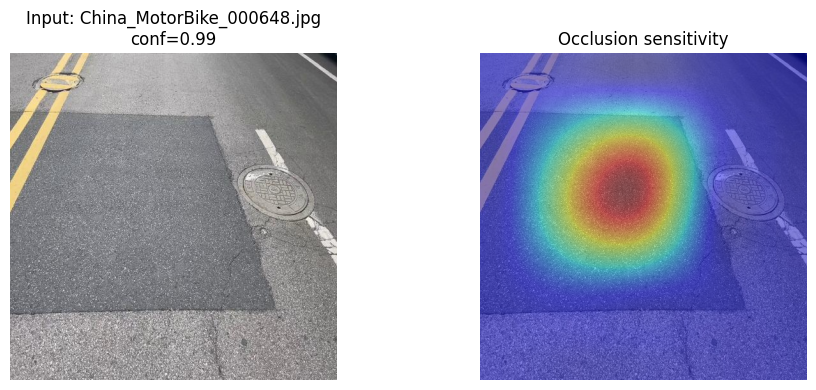

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.

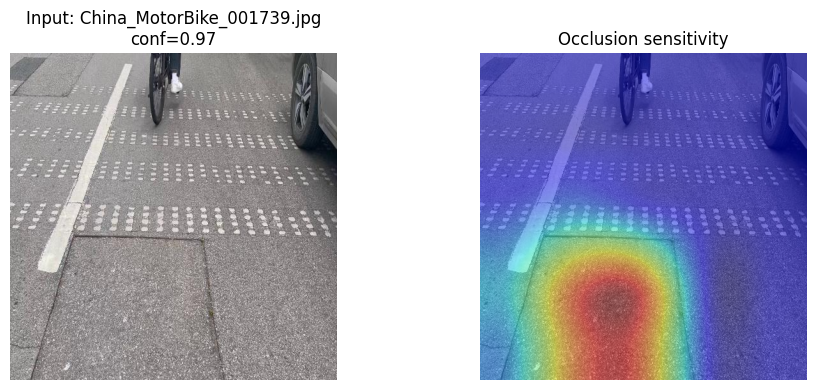

In [ ]:
# ============================================================
# 17. Lightweight explainability: occlusion sensitivity
# ============================================================
def predict_max_conf(model, image_path, imgsz=IMG_SIZE, conf=0.001):
    with torch.inference_mode():
        res=model.predict(str(image_path), imgsz=imgsz, conf=conf, max_det=60, batch=1, device=device, half=bool(torch.cuda.is_available()), verbose=False)[0]
    if res.boxes is None or len(res.boxes)==0: return 0.0
    return float(res.boxes.conf.detach().cpu().numpy().max())

def occlusion_sensitivity(image_path, weights_path, grid=5, imgsz=512):
    clear_gpu(); model=YOLO(str(weights_path))
    img=cv2.imread(str(image_path)); img=cv2.resize(img,(imgsz,imgsz))
    tmp=OUTPUT_DIR/"_xai_base.jpg"; cv2.imwrite(str(tmp), img)
    base=predict_max_conf(model, tmp, imgsz=imgsz)
    heat=np.zeros((grid,grid), dtype=np.float32); h,w=img.shape[:2]
    for gy in range(grid):
        for gx in range(grid):
            occ=img.copy(); y1,y2=int(gy*h/grid),int((gy+1)*h/grid); x1,x2=int(gx*w/grid),int((gx+1)*w/grid)
            occ[y1:y2,x1:x2]=cv2.GaussianBlur(occ[y1:y2,x1:x2],(31,31),0)
            tp=OUTPUT_DIR/f"_xai_{gy}_{gx}.jpg"; cv2.imwrite(str(tp), occ)
            heat[gy,gx]=max(0.0, base-predict_max_conf(model,tp,imgsz=imgsz))
    if heat.max()>0: heat/=heat.max()
    del model; clear_gpu(); return img, heat, base

xai_images=[Path(p) for p in test_score_df.sort_values("max_conf", ascending=False)["image"].head(2).tolist()]
for p in xai_images:
    img, heat, base=occlusion_sensitivity(p, FINAL_MODEL_PATH, grid=5, imgsz=min(IMG_SIZE,512))
    heat_up=cv2.resize(heat, (img.shape[1],img.shape[0]), interpolation=cv2.INTER_CUBIC)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title(f"Input: {p.name}\nconf={base:.2f}"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.imshow(heat_up, cmap="jet", alpha=.45); plt.title("Occlusion sensitivity"); plt.axis("off")
    plt.tight_layout(); plt.show()

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.


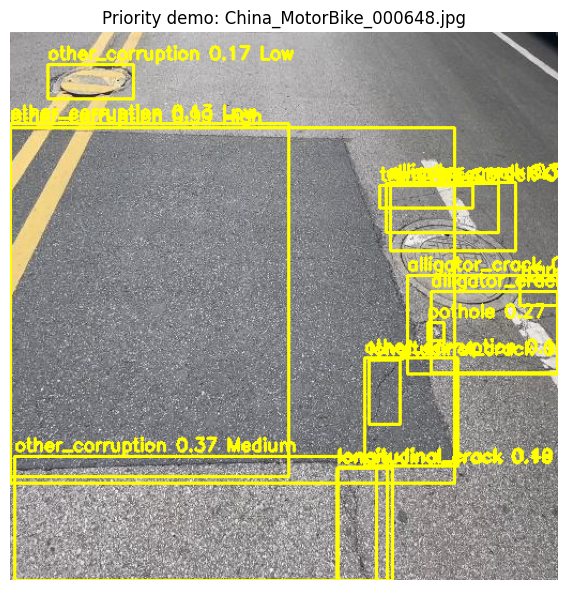

,class,confidence,area_ratio,priority_score,priority_label
0,other_corruption,0.991211,0.525589,8.920898,High
1,alligator_crack,0.775879,0.028676,5.773411,Medium
2,longitudinal_crack,0.492188,0.014557,1.414258,Low
3,alligator_crack,0.385742,0.034210,3.126527,Medium
4,alligator_crack,0.373779,0.018625,2.330526,Low
5,other_corruption,0.365723,0.153548,3.291504,Medium
6,pothole,0.269043,0.000944,1.383317,Low
7,longitudinal_crack,0.226807,0.006523,0.542383,Low
8,other_corruption,0.183594,0.033520,1.104643,Low
9,other_corruption,0.172119,0.009713,0.666821,Low


WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.


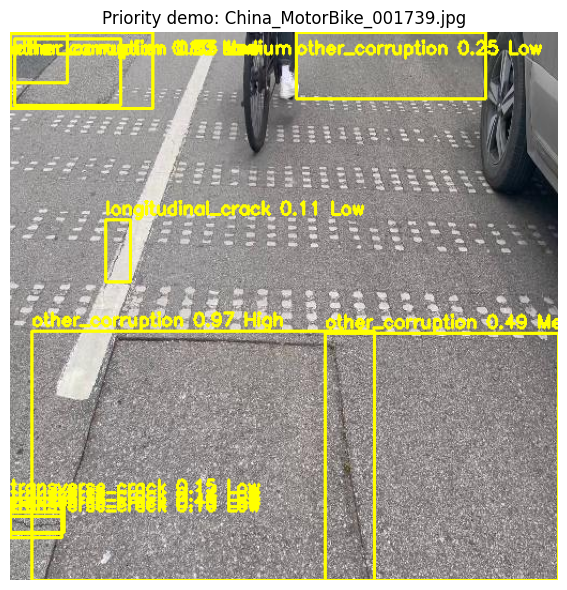

,class,confidence,area_ratio,priority_score,priority_label
0,other_corruption,0.968262,0.283370,8.714355,High
1,other_corruption,0.797363,0.036054,4.979414,Medium
2,transverse_crack,0.490234,0.003776,1.091526,Low
3,other_corruption,0.487305,0.191685,4.385742,Medium
4,other_corruption,0.331055,0.023486,1.692914,Low
5,other_corruption,0.250244,0.041989,1.696409,Low
6,transverse_crack,0.153076,0.006172,0.362841,Low
7,transverse_crack,0.139404,0.005590,0.325562,Low
8,other_corruption,0.133911,0.009388,0.514877,Low
9,longitudinal_crack,0.107422,0.004984,0.246969,Low


WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.


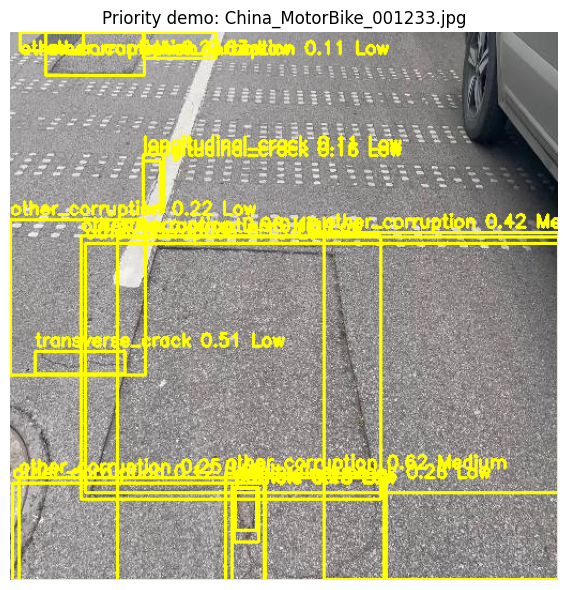

,class,confidence,area_ratio,priority_score,priority_label
0,other_corruption,0.959473,0.262222,8.635254,High
1,other_corruption,0.627930,0.014293,2.691529,Low
2,other_corruption,0.618652,0.057411,5.052538,Medium
3,transverse_crack,0.505859,0.006739,1.216262,Low
4,other_corruption,0.424316,0.269641,3.818848,Medium
5,longitudinal_crack,0.258301,0.010184,0.674438,Low
6,pothole,0.246582,0.004420,1.396404,Low
7,other_corruption,0.246582,0.125061,2.219238,Low
8,other_corruption,0.242188,0.003736,0.808005,Low
9,other_corruption,0.215332,0.070144,1.937988,Low


In [ ]:
# ============================================================
# 18. Maintenance priority scoring demo
# ============================================================
SEVERITY_WEIGHT={0:2,1:2,2:4,3:3,4:5}
def maintenance_priority_score(cls_id, conf, box, image_shape):
    h,w=image_shape[:2]; x1,y1,x2,y2=box
    area_ratio=max(0,x2-x1)*max(0,y2-y1)/max(1,h*w); severity=SEVERITY_WEIGHT.get(int(cls_id),1)
    score=severity*float(conf)*(1+min(area_ratio*30,2.0))
    label="High" if score>=6 else "Medium" if score>=3 else "Low"
    return float(score), label, float(area_ratio)

def run_priority_demo(image_path, weights_path, conf=OPERATING_CONF):
    clear_gpu(); model=YOLO(str(weights_path)); img=cv2.imread(str(image_path)); canvas=img.copy()
    r=model.predict(str(image_path), imgsz=IMG_SIZE, conf=conf, batch=1, device=device, half=bool(torch.cuda.is_available()), verbose=False)[0]
    rows=[]
    if r.boxes is not None and len(r.boxes):
        boxes=r.boxes.xyxy.detach().cpu().numpy(); clss=r.boxes.cls.detach().cpu().numpy().astype(int); confs=r.boxes.conf.detach().cpu().numpy()
        for box, cls_id, cf in zip(boxes,clss,confs):
            score,label,area=maintenance_priority_score(cls_id,cf,box,img.shape)
            x1,y1,x2,y2=map(int,box); name=CLASS_NAMES.get(int(cls_id), str(cls_id))
            cv2.rectangle(canvas,(x1,y1),(x2,y2),(0,255,255),2); cv2.putText(canvas,f"{name} {cf:.2f} {label}",(x1,max(20,y1-5)),cv2.FONT_HERSHEY_SIMPLEX,.55,(0,255,255),2)
            rows.append({"class":name,"confidence":float(cf),"area_ratio":area,"priority_score":score,"priority_label":label})
    del model; clear_gpu(); return canvas, pd.DataFrame(rows)

for p in [Path(p) for p in test_score_df.sort_values("max_conf", ascending=False)["image"].head(3).tolist()]:
    canvas, prdf = run_priority_demo(p, FINAL_MODEL_PATH)
    plt.figure(figsize=(8,6)); plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)); plt.title("Priority demo: "+p.name); plt.axis("off"); plt.tight_layout(); plt.show()
    display(prdf)

In [ ]:
# ============================================================
# 19. Create Flask app for local deployment
# ============================================================
APP_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(FINAL_MODEL_PATH, APP_DIR/"best.pt")
(APP_DIR/"requirements.txt").write_text("flask\nultralytics\nopencv-python\npillow\nnumpy\n", encoding="utf-8")

# Build app.py using a line list to avoid notebook quote issues.
lines = []
lines.append("from pathlib import Path")
lines.append("import cv2")
lines.append("from flask import Flask, request, render_template_string, send_from_directory")
lines.append("from ultralytics import YOLO")
lines.append("")
lines.append("APP_DIR=Path(__file__).resolve().parent")
lines.append("UPLOAD_DIR=APP_DIR/'uploads'; RESULT_DIR=APP_DIR/'results'")
lines.append("UPLOAD_DIR.mkdir(exist_ok=True); RESULT_DIR.mkdir(exist_ok=True)")
lines.append("MODEL_PATH=APP_DIR/'best.pt'")
lines.append(f"IMG_SIZE={IMG_SIZE}")
lines.append(f"CONF_THRESHOLD={OPERATING_CONF:.3f}")
lines.append("CLASS_NAMES=" + repr(CLASS_NAMES))
lines.append("SEVERITY_WEIGHT={0:2,1:2,2:4,3:3,4:5}")
lines.append("model=YOLO(str(MODEL_PATH))")
lines.append("app=Flask(__name__)")
lines.append("HTML = \"<h1>PotholeLens</h1><p>Academic decision-support prototype only.</p><form method='post' enctype='multipart/form-data'><input type='file' name='image' required><button>Detect</button></form>{% if result_image %}<h2>Result</h2><img style='max-width:900px' src='/results/{{result_image}}'>{{table|safe}}{% endif %}\"")
lines.append("def priority(cls_id, conf, box, shape):")
lines.append("    h,w=shape[:2]; x1,y1,x2,y2=box")
lines.append("    area=max(0,x2-x1)*max(0,y2-y1)/max(1,h*w); sev=SEVERITY_WEIGHT.get(int(cls_id),1)")
lines.append("    score=sev*float(conf)*(1+min(area*30,2.0)); label='High' if score>=6 else 'Medium' if score>=3 else 'Low'")
lines.append("    return score,label,area")
lines.append("@app.route('/', methods=['GET','POST'])")
lines.append("def index():")
lines.append("    result_image=None; table=''")
lines.append("    if request.method=='POST':")
lines.append("        f=request.files['image']; inp=UPLOAD_DIR/f.filename; f.save(inp)")
lines.append("        img=cv2.imread(str(inp)); canvas=img.copy(); rows=[]")
lines.append("        r=model.predict(str(inp), imgsz=IMG_SIZE, conf=CONF_THRESHOLD, verbose=False)[0]")
lines.append("        if r.boxes is not None and len(r.boxes):")
lines.append("            for box,cls_id,cf in zip(r.boxes.xyxy.cpu().numpy(), r.boxes.cls.cpu().numpy().astype(int), r.boxes.conf.cpu().numpy()):")
lines.append("                x1,y1,x2,y2=map(int,box); name=CLASS_NAMES.get(int(cls_id),str(cls_id)); score,label,area=priority(cls_id,cf,box,img.shape)")
lines.append("                cv2.rectangle(canvas,(x1,y1),(x2,y2),(0,255,255),2); cv2.putText(canvas,f'{name} {cf:.2f} {label}',(x1,max(20,y1-5)),cv2.FONT_HERSHEY_SIMPLEX,.55,(0,255,255),2)")
lines.append("                rows.append([name, f'{cf:.3f}', f'{area:.4f}', f'{score:.2f}', label])")
lines.append("        out='result_'+f.filename; cv2.imwrite(str(RESULT_DIR/out), canvas); result_image=out")
lines.append("        if rows:")
lines.append("            table='<table border=1 cellpadding=6><tr><th>Class</th><th>Confidence</th><th>Area</th><th>Priority score</th><th>Priority</th></tr>'")
lines.append("            for row in rows: table += '<tr>' + ''.join(f'<td>{x}</td>' for x in row) + '</tr>'")
lines.append("            table += '</table>'")
lines.append("        else: table='<p>No damage detected at selected confidence.</p>'")
lines.append("    return render_template_string(HTML, result_image=result_image, table=table)")
lines.append("@app.route('/results/<path:name>')")
lines.append("def results(name): return send_from_directory(RESULT_DIR,name)")
lines.append("if __name__=='__main__': app.run(debug=True)")

app_code = "\n".join(lines) + "\n"
(APP_DIR/"app.py").write_text(app_code, encoding="utf-8")
(APP_DIR/"README.md").write_text(f"# PotholeLens Flask App\n\nRun: pip install -r requirements.txt && python app.py\n\nModel: {FINAL_MODEL_NAME}\nThreshold: {OPERATING_CONF:.3f}\n", encoding="utf-8")
zip_path=PROJECT_DIR/"potholelens_flask_app.zip"
with zipfile.ZipFile(zip_path,"w",zipfile.ZIP_DEFLATED) as z:
    for file in APP_DIR.rglob("*"):
        z.write(file, file.relative_to(APP_DIR.parent))
print("Flask app zip:", zip_path)

Flask app zip: /kaggle/working/potholelens_final_gpu_safe/potholelens_flask_app.zip


In [ ]:
# ============================================================
# 20. Save and zip all outputs
# ============================================================
summary={"run_mode":RUN_MODE,"models_compared":MODEL_CANDIDATES,"selected_model":FINAL_MODEL_NAME,"final_model_path":str(FINAL_MODEL_PATH),"img_size":IMG_SIZE,"operating_confidence":OPERATING_CONF,"final_detection_metrics":final_metrics,"test_operating_metrics":test_operating_df.to_dict(orient="records"),"ethics":"UREC1 secondary dataset only; no participants or fieldwork."}
(OUTPUT_DIR/"experiment_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))
all_zip=Path("/kaggle/working/potholelens_final_outputs.zip")
with zipfile.ZipFile(all_zip,"w",zipfile.ZIP_DEFLATED) as z:
    for file in PROJECT_DIR.rglob("*"):
        if file.is_file(): z.write(file, file.relative_to(PROJECT_DIR.parent))
print("All outputs zipped:", all_zip)

{
  "run_mode": "gpu_safe",
  "models_compared": [
    "yolov8s.pt",
    "yolov8m.pt",
    "yolo11s.pt"
  ],
  "selected_model": "yolov8s.pt",
  "final_model_path": "/kaggle/working/potholelens_final_gpu_safe/runs/final_yolov8s_512_gpu_safe/weights/best.pt",
  "img_size": 512,
  "operating_confidence": 0.1,
  "final_detection_metrics": {
    "model": "yolov8s.pt",
    "weights": "/kaggle/working/potholelens_final_gpu_safe/runs/final_yolov8s_512_gpu_safe/weights/best.pt",
    "val_precision": 0.5379235915493344,
    "val_recall": 0.45208519471219094,
    "val_F1": 0.4912830976868127,
    "val_mAP50": 0.470611612926857,
    "val_mAP50_95": 0.2061877309096466,
    "test_precision": 0.5142144235714584,
    "test_recall": 0.4825031740536807,
    "test_F1": 0.49785434130706613,
    "test_mAP50": 0.45994951618707597,
    "test_mAP50_95": 0.1985110024440805,
    "test_inference_ms": 8.70089749428124
  },
  "test_operating_metrics": [
    {
      "conf_threshold": 0.1,
      "accuracy": 0.89714

## Reporting guidance

Use the final printed values exactly:

- If `Test image-level accuracy >= 0.85`, write: **85%+ image-level damage-detection accuracy**.
- If `Test operating precision >= 0.85`, write: **85%+ operating precision**.
- Do **not** write **85% mAP** unless mAP itself is 0.85 or above.

This avoids confusing classification-style accuracy with object-detection mAP.

In [ ]:
import os
import shutil
from IPython.display import display, FileLink, Javascript

source_dir = "/kaggle/working"
zip_name = "kaggle_working_backup.zip"
final_zip = os.path.join(source_dir, zip_name)
temporary_base = "/tmp/kaggle_working_backup"

# Delete previous archives so they are not included inside the new ZIP
for path in [final_zip, temporary_base + ".zip"]:
    if os.path.exists(path):
        os.remove(path)

print("Creating ZIP of the entire /kaggle/working directory...")
print("Please wait. Large folders may take several minutes.")

temporary_zip = shutil.make_archive(
    base_name=temporary_base,
    format="zip",
    root_dir="/kaggle",
    base_dir="working"
)

# Move the completed ZIP into /kaggle/working
shutil.move(temporary_zip, final_zip)

size_gb = os.path.getsize(final_zip) / (1024 ** 3)

print("\nZIP created successfully.")
print(f"Location: {final_zip}")
print(f"Size: {size_gb:.2f} GB")
print("Starting download automatically...")

# Change to the directory containing the ZIP
os.chdir(source_dir)

# Show a manual link as a fallback
display(FileLink(zip_name))

# Attempt to start the browser download automatically
display(Javascript(f"""
setTimeout(function() {{
    const downloadLink = document.createElement("a");
    downloadLink.href = "files/{zip_name}";
    downloadLink.download = "{zip_name}";
    document.body.appendChild(downloadLink);
    downloadLink.click();
    document.body.removeChild(downloadLink);
}}, 1500);
"""))

Creating ZIP of the entire /kaggle/working directory...
Please wait. Large folders may take several minutes.

ZIP created successfully.
Location: /kaggle/working/kaggle_working_backup.zip
Size: 5.03 GB
Starting download automatically...


/kaggle/working/kaggle_working_backup.zip

<IPython.core.display.Javascript object>